=== [1. Simple Linear Regression Output] ===
Intercept (b0): 40.01
Coefficient (b1): 1.49
Mean Squared Error (MSE): 20.91
R-squared (R2 Score): 0.86


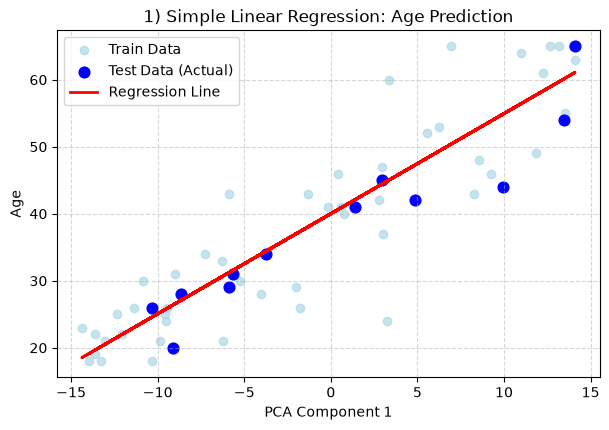

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#Lab1 Regression
#Simple Linear Regression
# 1. โหลดข้อมูล
df = pd.read_csv('face_dataset_v2.csv')

# 2. กำหนด Feature (X) และ Target (y)
X_simple = df[['PCA_Component_1']]
y = df['Age']

# 3. แบ่งข้อมูล Train 80% (48 ตัวอย่าง) และ Test 20% (12 ตัวอย่าง)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# 4. สร้างและเทรนโมเดล
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

# 5. ทำนายผล
y_pred_s = model_simple.predict(X_test_s)

print("=== [1. Simple Linear Regression Output] ===")
print(f"Intercept (b0): {model_simple.intercept_:.2f}")
print(f"Coefficient (b1): {model_simple.coef_[0]:.2f}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_s, y_pred_s):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test_s, y_pred_s):.2f}")

# 6. วาดกราฟจุดกระจาย (Scatter Plot) พร้อมเส้น Regression Line
plt.figure(figsize=(7, 4.5))
plt.scatter(X_train_s, y_train_s, color='lightblue', label='Train Data', alpha=0.7)
plt.scatter(X_test_s, y_test_s, color='blue', label='Test Data (Actual)', s=60)
plt.plot(X_simple, model_simple.predict(X_simple), color='red', linewidth=2, label='Regression Line')
plt.title('1) Simple Linear Regression: Age Prediction')
plt.xlabel('PCA Component 1')
plt.ylabel('Age')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

=== [2. Multiple Linear Regression Output] ===
Intercept (b0): 39.65
Coefficients: [1.44 0.63 0.06 0.63 0.32]
Mean Squared Error (MSE): 13.85
R-squared (R2 Score): 0.91


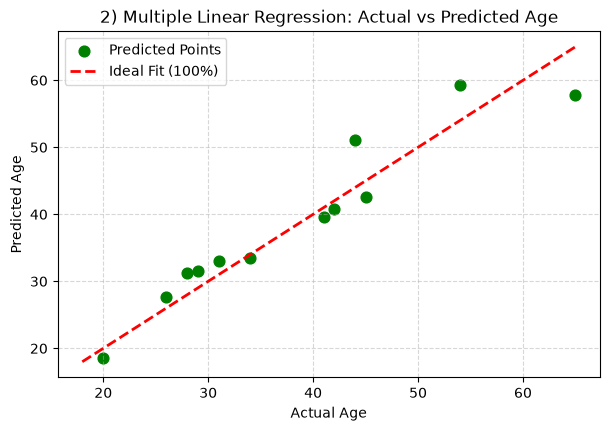

In [3]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#LAB 1: Regression
# Multiple Linear Regression 
# 1. กำหนด Features ทั้งหมด (X) และ Target (y)
X_multi = df[['PCA_Component_1', 'PCA_Component_2', 'PCA_Component_3', 'PCA_Component_4', 'PCA_Component_5']]
y = df['Age']

# 2. แบ่งข้อมูล Train / Test
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# 3. สร้างและเทรนโมเดล
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# 4. ทำนายผล
y_pred_m = model_multi.predict(X_test_m)

print("=== [2. Multiple Linear Regression Output] ===")
print(f"Intercept (b0): {model_multi.intercept_:.2f}")
print(f"Coefficients: {np.round(model_multi.coef_, 2)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_m, y_pred_m):.2f}")
print(f"R-squared (R2 Score): {r2_score(y_test_m, y_pred_m):.2f}")

# 5. วาดกราฟเปรียบเทียบ ค่าจริง (Actual) vs ค่าทำนาย (Predicted)
plt.figure(figsize=(7, 4.5))
plt.scatter(y_test_m, y_pred_m, color='green', s=60, label='Predicted Points')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal Fit (100%)')
plt.title('2) Multiple Linear Regression: Actual vs Predicted Age')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [4]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#LAB 1: Regression
#Age Prediction S
print("=== [3. Age Prediction Testing] ===")

# สมมติข้อมูลภาพใบหน้าใหม่ 1 ใบหน้า
new_face = pd.DataFrame([{
    'PCA_Component_1': 8.5,
    'PCA_Component_2': -2.1,
    'PCA_Component_3': 1.0,
    'PCA_Component_4': -0.5,
    'PCA_Component_5': 0.8
}])

# ทำนายผล
pred_simple = model_simple.predict(new_face[['PCA_Component_1']])[0]
pred_multi = model_multi.predict(new_face)[0]

print("ผลการทำนายอายุสำหรับภาพใบหน้าใหม่:")
print(f"• Simple Linear Regression  : {pred_simple:.1f} ปี")
print(f"• Multiple Linear Regression: {pred_multi:.1f} ปี")

# ตารางสรุปเปรียบเทียบประสิทธิภาพบน Test Set
comparison_df = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Multiple Linear Regression'],
    'MSE': [mean_squared_error(y_test_s, y_pred_s), mean_squared_error(y_test_m, y_pred_m)],
    'R2 Score': [r2_score(y_test_s, y_pred_s), r2_score(y_test_m, y_pred_m)]
})

print("\n--- ตารางเปรียบเทียบประสิทธิภาพโมเดล ---")
display(comparison_df)

=== [3. Age Prediction Testing] ===
ผลการทำนายอายุสำหรับภาพใบหน้าใหม่:
• Simple Linear Regression  : 52.7 ปี
• Multiple Linear Regression: 50.5 ปี

--- ตารางเปรียบเทียบประสิทธิภาพโมเดล ---


,Model,MSE,R2 Score
0,Simple Linear Regression,20.909209,0.861241
1,Multiple Linear Regression,13.848648,0.908097


In [14]:
#LAB 2: Classification
#Preparing Classification Data  
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. โหลดข้อมูลจากไฟล์ CSV
df = pd.read_csv('face_dataset_v2.csv')

# 2. แปลงข้อมูลเชิงคุณภาพ (Categorical) ให้เป็นตัวเลข (Numeric)
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])

# 3. กำหนดตัวแปรต้น (X) และตัวแปรเป้าหมาย (y)
X = df[['PCA_Component_1', 'PCA_Component_2']]  # ใช้ 2 Components เพื่อนำไปพล็อตกราฟ 2D ได้
y = df['Gender_Encoded']

# 4. แบ่งข้อมูลออกเป็น ชุดฝึกสอน (80%) และ ชุดทดสอบ (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("จำนวนข้อมูล Train Set:", len(X_train))
print("จำนวนข้อมูล Test Set:", len(X_test))
print("การแปลงคลาส (Classes):", dict(zip(le.classes_, le.transform(le.classes_))))

จำนวนข้อมูล Train Set: 48
จำนวนข้อมูล Test Set: 12
การแปลงคลาส (Classes): {'Female': np.int64(0), 'Male': np.int64(1)}


In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#LAB 2: Classification
#Decision Boundary Visualization
from sklearn.linear_model import LogisticRegression

# 1. ประกาศสร้างโมเดล Logistic Regression
model_log = LogisticRegression()

# 2. ฝึกสอนโมเดลด้วย Train Set
model_log.fit(X_train, y_train)

# 3. ให้โมเดลทำนายผลบน Test Set
y_pred = model_log.predict(X_test)

print("น้ำหนักสัมประสิทธิ์ (Coefficients):", model_log.coef_)
print("จุดตัดแกน (Intercept):", model_log.intercept_)

น้ำหนักสัมประสิทธิ์ (Coefficients): [[-0.00923317 -0.26508023]]
จุดตัดแกน (Intercept): [-0.06483107]


In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#LAB 2: Classification
#Logistic Regression
# 1. สมมติข้อมูลภาพใบหน้าใหม่ 1 ใบหน้า (มีค่า PCA Component 1 และ 2)
new_face = pd.DataFrame([{
    'PCA_Component_1': -8.5,
    'PCA_Component_2': 4.2
}])

# 2. ทำนายคลาสเพศ (0 หรือ 1)
pred_class = model_log.predict(new_face)[0]
pred_gender = le.inverse_transform([pred_class])[0]

# 3. คำนวณค่าความน่าจะเป็น (%)
pred_prob = model_log.predict_proba(new_face)[0]

print("=== [ Gender Prediction Result ] ===")
print(f"ผลการทำนายเพศ   : {pred_gender}")
print(f"ความน่าจะเป็น (Female): {pred_prob[0]*100:.2f}%")
print(f"ความน่าจะเป็น (Male)  : {pred_prob[1]*100:.2f}%")

=== [ Gender Prediction Result ] ===
ผลการทำนายเพศ   : Female
ความน่าจะเป็น (Female): 75.02%
ความน่าจะเป็น (Male)  : 24.98%


c:\Users\Net4360\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


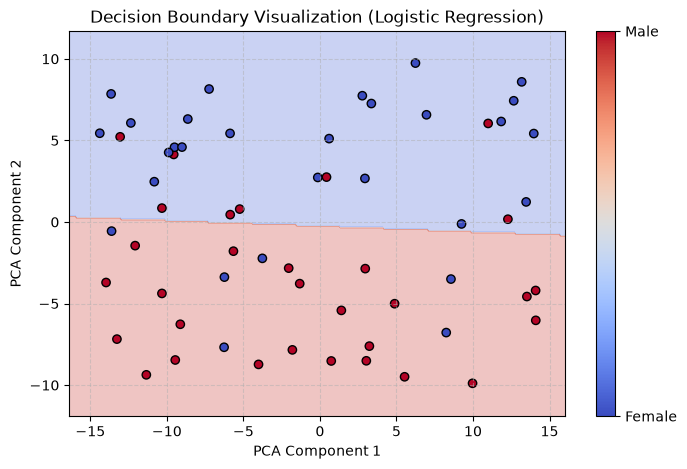

In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#LAB 2: Classification
#Gender Prediction
# 1. สร้างตารางพิกัด Meshgrid ครอบคลุมขอบเขตของข้อมูล
x_min, x_max = X['PCA_Component_1'].min() - 2, X['PCA_Component_1'].max() + 2
y_min, y_max = X['PCA_Component_2'].min() - 2, X['PCA_Component_2'].max() + 2
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# 2. ให้โมเดลทำนายผลทุกๆ พิกัดบน Meshgrid
Z = model_log.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 3. พล็อตกราฟ Decision Boundary และจุดข้อมูล
plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X['PCA_Component_1'], X['PCA_Component_2'], c=y, cmap=plt.cm.coolwarm, edgecolors='k')

# 4. ตกแต่งรายละเอียดกราฟ
plt.title('Decision Boundary Visualization (Logistic Regression)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, ticks=[0, 1], format=plt.FuncFormatter(lambda val, loc: le.inverse_transform([int(val)])[0]))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

C:\Users\Net4360\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Net4360\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Net4360\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Net4360\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Net4360\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: Us

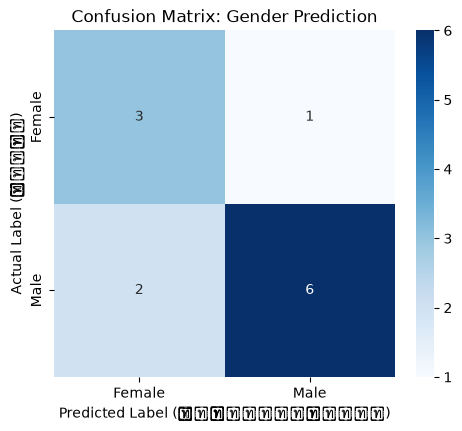

=== [ Model Performance Metrics ] ===
Accuracy  (ความถูกต้องรวม) : 75.00%
Precision (ความแม่นยำ)     : 85.71%
Recall    (ความครอบคลุม)   : 75.00%
F1-Score  (ค่าเฉลี่ยสอดคล้อง) : 80.00%


In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#LAB 2: Classification
#Confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 1. คำนวณ Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# 2. วาดกราฟ Heatmap ของ Confusion Matrix
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Gender Prediction')
plt.xlabel('Predicted Label (ค่าที่โมเดลทำนาย)')
plt.ylabel('Actual Label (ค่าจริง)')
plt.show()

# 3. คำนวณตัววัดประสิทธิภาพต่างๆ
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=== [ Model Performance Metrics ] ===")
print(f"Accuracy  (ความถูกต้องรวม) : {acc*100:.2f}%")
print(f"Precision (ความแม่นยำ)     : {prec*100:.2f}%")
print(f"Recall    (ความครอบคลุม)   : {rec*100:.2f}%")
print(f"F1-Score  (ค่าเฉลี่ยสอดคล้อง) : {f1*100:.2f}%")

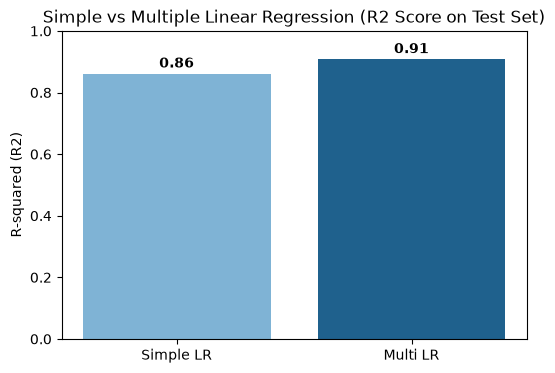

In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#LAB 3: Model Comparison 
#Simple vs Multiple Linear Regression
import matplotlib.pyplot as plt

# 1. กำหนดชื่อโมเดลและดึงค่า R2 ที่เคยคำนวณไว้มาใส่ลิสต์
models = ['Simple LR', 'Multi LR']
r2_scores = [r2_score(y_test_s, y_pred_s), r2_score(y_test_m, y_pred_m)]

# 2. วาดกราฟแท่งเปรียบเทียบ
plt.figure(figsize=(6, 4))
plt.bar(models, r2_scores, color=['#7fb3d5', '#1f618d'])
plt.title('Simple vs Multiple Linear Regression (R2 Score on Test Set)')
plt.ylabel('R-squared (R2)')
plt.ylim(0, 1) # กำหนดแกน Y ให้อยู่ในช่วง 0 ถึง 1

# 3. วนลูปเพื่อเขียนตัวเลขกำกับไว้บนกราฟแท่ง
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
    
plt.show()

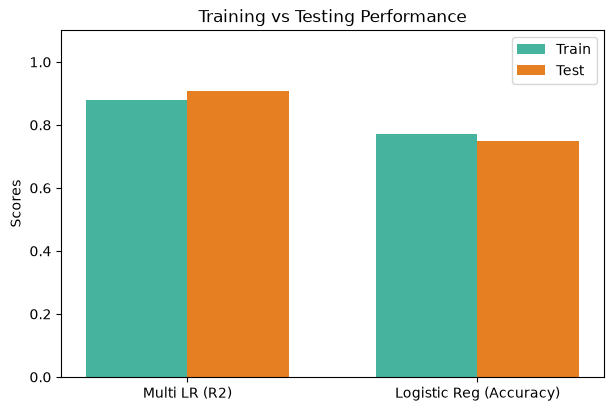

In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#LAB 3: Model Comparison 
#Training vs Testing Performance
# 1. รวบรวมคะแนนฝั่ง Train (ต้องเอา X_train ไปทำนายผลมาเทียบกับ y_train)
train_scores = [
    r2_score(y_train_m, model_multi.predict(X_train_m)), 
    accuracy_score(y_train, model_log.predict(X_train))
]

# 2. รวบรวมคะแนนฝั่ง Test (ที่เคยทำนายไว้แล้ว)
test_scores = [
    r2_score(y_test_m, y_pred_m), 
    accuracy_score(y_test, y_pred)
]
labels = ['Multi LR (R2)', 'Logistic Reg (Accuracy)']

# 3. ตั้งค่าตำแหน่งสำหรับกราฟแท่งคู่
x = np.arange(len(labels))
width = 0.35

# 4. สร้างกราฟแท่งคู่ (Grouped Bar Chart)
fig, ax = plt.subplots(figsize=(7, 4.5))
rects1 = ax.bar(x - width/2, train_scores, width, label='Train', color='#45b39d')
rects2 = ax.bar(x + width/2, test_scores, width, label='Test', color='#e67e22')

# 5. ตกแต่งกราฟ
ax.set_ylabel('Scores')
ax.set_title('Training vs Testing Performance')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1.1)
plt.show()

In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#LAB 3: Model Comparison 
#Regression vs Classification
#เทียบความแตกต่างระหว่างRegressionและClassification

In [ ]:
#นายธนกฤต ชูจิต sec2 รหัส116710400148-8
#LAB 3: Model Comparison 
#Model Performance Metrics
print("==================================================")
print("       SUMMARY: MODEL PERFORMANCE METRICS")
print("==================================================")
print("[1] Regression Metrics (ทำนายอายุ)")
print(f"    - Mean Squared Error (MSE) : {mean_squared_error(y_test_m, y_pred_m):.2f}")
print(f"    - R-squared (R2 Score)     : {r2_score(y_test_m, y_pred_m):.2f}")
print("-" * 50)
print("[2] Classification Metrics (จำแนกเพศ)")
print(f"    - Accuracy  : {accuracy_score(y_test, y_pred):.2f}")
print(f"    - Precision : {precision_score(y_test, y_pred):.2f}")
print(f"    - Recall    : {recall_score(y_test, y_pred):.2f}")
print(f"    - F1-Score  : {f1_score(y_test, y_pred):.2f}")
print("==================================================")

       SUMMARY: MODEL PERFORMANCE METRICS
[1] Regression Metrics (ทำนายอายุ)
    - Mean Squared Error (MSE) : 13.85
    - R-squared (R2 Score)     : 0.91
--------------------------------------------------
[2] Classification Metrics (จำแนกเพศ)
    - Accuracy  : 0.75
    - Precision : 0.86
    - Recall    : 0.75
    - F1-Score  : 0.80
